<a href="https://colab.research.google.com/github/kasugy/CheckPoint/blob/main/Proyecto_M%C3%B3dulo_9_%7C_ABP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Spark versión: 4.0.2
Total transacciones: 10
Gasto por cliente (RDD): [(102, 74.99), (104, 225.75), (101, 535.49), (103, 325.5), (105, 99.99)]
Transacciones > 100: 4
Linaje de trans_parsed:
b'(2) PythonRDD[357] at RDD at PythonRDD.scala:56 []\n |  ParallelCollectionRDD[349] at readRDDFromFile at PythonRDD.scala:297 []'
Ventas por categoría:
+-----------+------------------+---------+
|  categoria|      total_ventas|num_trans|
+-----------+------------------+---------+
|Electronica|            745.49|        4|
|      Hogar|             325.5|        2|
|       Ropa|            144.99|        2|
|  Alimentos|45.739999999999995|        2|
+-----------+------------------+---------+

Top clientes (gasto total):
+------+-------------+
|nombre|total_gastado|
+------+-------------+
|   Ana|       535.49|
| Marta|        325.5|
| Jorge|       225.75|
| Lucia|        99.99|
|  Luis|        74.99|
+------+-------------+

Datos guardados en Parquet
AUC del modelo de clasificación: 1.0000
Silhouett

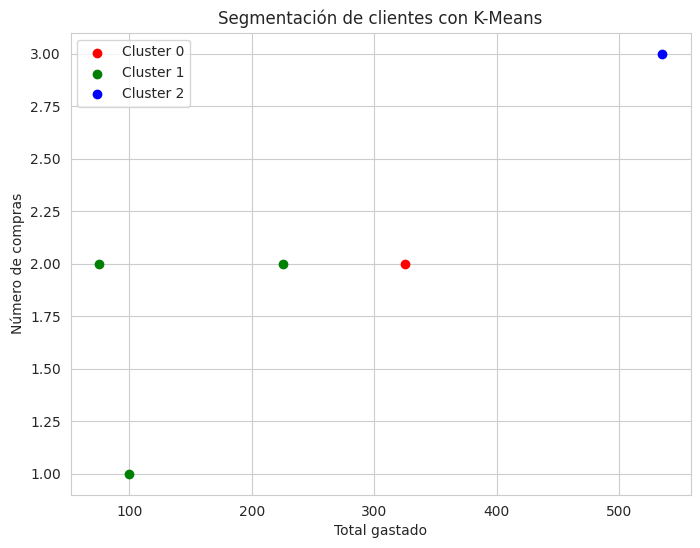

/tmp/ipykernel_7011/2356307159.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_counts, x="label", y="count", palette="Set2")


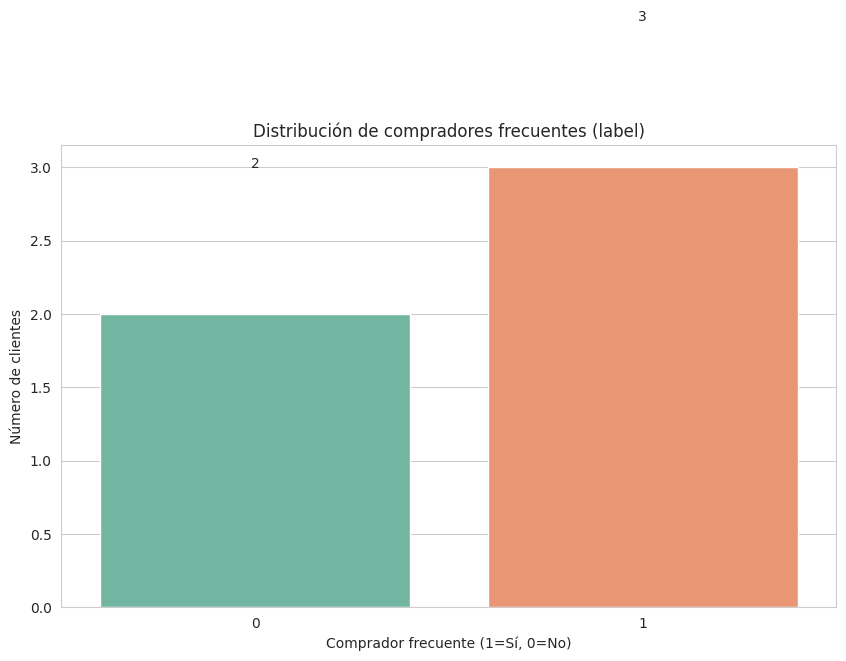

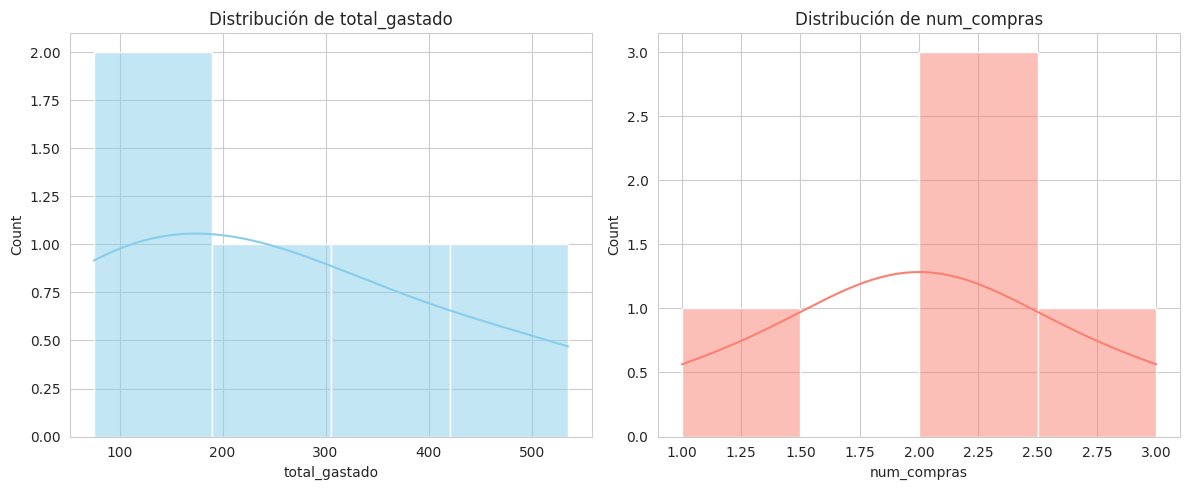

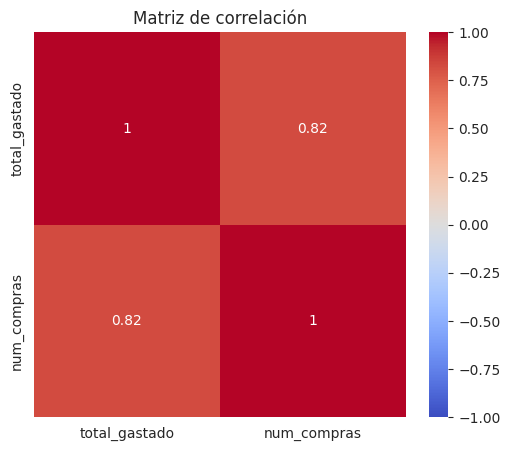

No se puede generar la curva ROC: el conjunto de prueba tiene solo una clase.



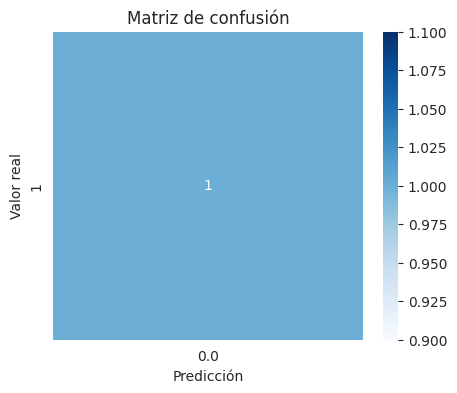

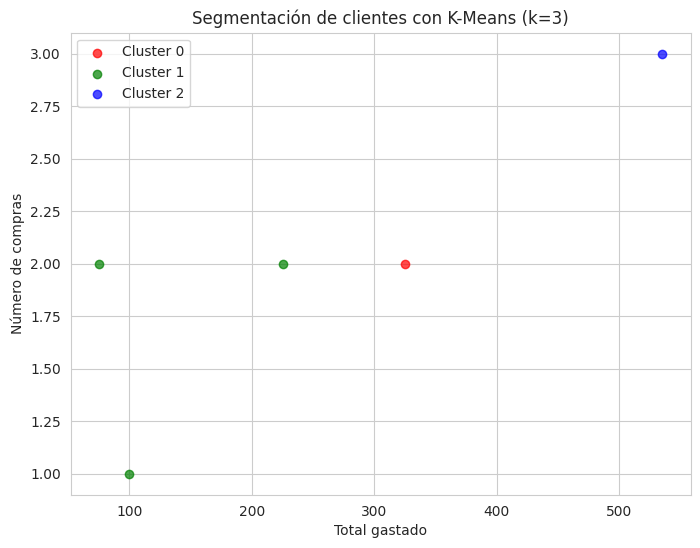

Proyecto completado exitosamente.


In [4]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType, StringType
from pyspark.sql.functions import sum as _sum, count
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import BinaryClassificationEvaluator, ClusteringEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Crear SparkSession (punto de entrada)
spark = SparkSession.builder \
    .appName("Retail_Analytics_Pipeline") \
    .config("spark.sql.shuffle.partitions", "4") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext
print("Spark versión:", spark.version)

# =====================================================
# 2. Datos simulados (Lección 3 - RDDs)
# =====================================================
# Transacciones: id, cliente_id, fecha, monto, categoria, producto
transacciones_raw = [
    "1,101,2024-01-15,125.50,Electronica,Tablet",
    "2,102,2024-01-16,45.00,Ropa,Playera",
    "3,101,2024-01-20,89.99,Electronica,Auriculares",
    "4,103,2024-01-22,250.00,Hogar,Sarten",
    "5,104,2024-01-23,15.75,Alimentos,Cafe",
    "6,101,2024-01-25,320.00,Electronica,Monitor",
    "7,105,2024-01-26,99.99,Ropa,Chaqueta",
    "8,102,2024-01-27,29.99,Alimentos,Vino",
    "9,103,2024-01-28,75.50,Hogar,Cojin",
    "10,104,2024-01-29,210.00,Electronica,Teclado"
]

# Crear RDD
transacciones_rdd = sc.parallelize(transacciones_raw)
print("Total transacciones:", transacciones_rdd.count())

# Parsear: (cliente_id, monto, categoria)
def parsear(linea):
    campos = linea.split(",")
    return (int(campos[1]), float(campos[3]), campos[4])

trans_parsed = transacciones_rdd.map(parsear)

# Pair RDD: (cliente, monto) para agregar gasto
cliente_monto = trans_parsed.map(lambda x: (x[0], x[1]))
gasto_por_cliente = cliente_monto.reduceByKey(lambda a,b: a+b)
print("Gasto por cliente (RDD):", gasto_por_cliente.collect())

# Transformaciones adicionales: transacciones con monto > 100
trans_grandes = trans_parsed.filter(lambda x: x[1] > 100)
print("Transacciones > 100:", trans_grandes.count())

# Mostrar linaje (DAG)
print("Linaje de trans_parsed:")
print(trans_parsed.toDebugString())

# =====================================================
# 3. Convertir a DataFrame y usar Spark SQL (Lección 4)
# =====================================================
# Crear DataFrame con esquema explícito
schema = StructType([
    StructField("cliente_id", IntegerType(), True),
    StructField("monto", DoubleType(), True),
    StructField("categoria", StringType(), True)
])
df_transacciones = spark.createDataFrame(trans_parsed, schema)
df_transacciones.createOrReplaceTempView("ventas")

# Datos de clientes (simulados)
clientes_data = [(101, "Ana", "Madrid"), (102, "Luis", "Barcelona"),
                 (103, "Marta", "Valencia"), (104, "Jorge", "Madrid"),
                 (105, "Lucia", "Sevilla")]
clientes_df = spark.createDataFrame(clientes_data, ["cliente_id", "nombre", "ciudad"])
clientes_df.createOrReplaceTempView("clientes")

# Consultas SQL
print("Ventas por categoría:")
spark.sql("""
    SELECT categoria, SUM(monto) as total_ventas, COUNT(*) as num_trans
    FROM ventas
    GROUP BY categoria
    ORDER BY total_ventas DESC
""").show()

print("Top clientes (gasto total):")
spark.sql("""
    SELECT c.nombre, SUM(v.monto) as total_gastado
    FROM ventas v JOIN clientes c ON v.cliente_id = c.cliente_id
    GROUP BY c.nombre
    ORDER BY total_gastado DESC
""").show()

# Guardar en Parquet
df_transacciones.write.mode("overwrite").parquet("resultados_ventas.parquet")
df_enriquecido = df_transacciones.join(clientes_df, on="cliente_id")
df_enriquecido.write.mode("overwrite").parquet("ventas_clientes.parquet")
print("Datos guardados en Parquet")

# =====================================================
# 4. Machine Learning con MLlib (Lección 5)
# =====================================================
# Cargar datos enriquecidos
df_ml = spark.read.parquet("ventas_clientes.parquet")

# Agregar por cliente: total gastado, número de compras
df_cliente = df_ml.groupBy("cliente_id", "nombre", "ciudad").agg(
    _sum("monto").alias("total_gastado"),
    count("monto").alias("num_compras")
)

# Crear etiqueta para clasificación: comprador frecuente si total_gastado > 200
df_cliente = df_cliente.withColumn("label", (df_cliente.total_gastado > 200).cast("int"))

# Dividir entrenamiento y prueba
train, test = df_cliente.randomSplit([0.7, 0.3], seed=42)

# Pipeline de preprocesamiento y modelo
indexer = StringIndexer(inputCol="ciudad", outputCol="ciudad_idx", handleInvalid="keep")
assembler = VectorAssembler(inputCols=["total_gastado", "num_compras", "ciudad_idx"], outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)

pipeline_lr = Pipeline(stages=[indexer, assembler, scaler, lr])
model_lr = pipeline_lr.fit(train)

# Evaluación clasificación
pred_lr = model_lr.transform(test)
evaluator_roc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator_roc.evaluate(pred_lr)
print(f"AUC del modelo de clasificación: {auc:.4f}")

# Modelo no supervisado: K-Means
kmeans = KMeans(featuresCol="features", k=3, seed=42)
pipeline_kmeans = Pipeline(stages=[indexer, assembler, scaler, kmeans])
model_kmeans = pipeline_kmeans.fit(df_cliente)
pred_kmeans = model_kmeans.transform(df_cliente)

# Evaluación clustering
evaluator_sil = ClusteringEvaluator(featuresCol="features", predictionCol="prediction", metricName="silhouette")
silhouette = evaluator_sil.evaluate(pred_kmeans)
print(f"Silhouette Score para K-Means: {silhouette:.4f}")

# Guardar modelos
model_lr.write().overwrite().save("modelo_lr_retail")
model_kmeans.write().overwrite().save("modelo_kmeans_retail")

# =====================================================
# 5. Visualización de clusters
# =====================================================
pdf = pred_kmeans.select("total_gastado", "num_compras", "prediction").toPandas()
plt.figure(figsize=(8,6))
colores = ['red', 'green', 'blue']
for i in range(3):
    subset = pdf[pdf.prediction == i]
    plt.scatter(subset.total_gastado, subset.num_compras, c=colores[i], label=f'Cluster {i}')
plt.xlabel("Total gastado")
plt.ylabel("Número de compras")
plt.title("Segmentación de clientes con K-Means")
plt.legend()
plt.savefig("clusters_clientes.png")
plt.show()

# =====================================================
# Visualizaciones adicionales
# =====================================================

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Distribución de la variable objetivo (label)
# Se asume que df_cliente ya existe (DataFrame de Spark con columna "label")
label_counts = df_cliente.groupBy("label").count().toPandas()
plt.figure()
sns.barplot(data=label_counts, x="label", y="count", palette="Set2")
plt.title("Distribución de compradores frecuentes (label)")
plt.xlabel("Comprador frecuente (1=Sí, 0=No)")
plt.ylabel("Número de clientes")
for i, row in label_counts.iterrows():
    plt.text(row["label"], row["count"] + 1, str(row["count"]), ha='center')
plt.savefig("distribucion_label.png")
plt.show()

# 2. Histogramas de características (total_gastado, num_compras)
# Tomamos una muestra de 1000 registros
sample_pdf = df_cliente.select("total_gastado", "num_compras").limit(1000).toPandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(sample_pdf["total_gastado"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribución de total_gastado")
sns.histplot(sample_pdf["num_compras"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribución de num_compras")
plt.tight_layout()
plt.savefig("histogramas_caracteristicas.png")
plt.show()

# 3. Matriz de correlación (solo para características numéricas)
# (Se necesita pandas; convertimos una muestra)
corr_pdf = df_cliente.select("total_gastado", "num_compras").limit(2000).toPandas()
corr_matrix = corr_pdf.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Matriz de correlación")
plt.savefig("matriz_correlacion.png")
plt.show()

# 4. Curva ROC (usando predicciones del modelo de regresión logística)
# pred_lr es el DataFrame de Spark con columnas "label" y "probability"
roc_pdf = pred_lr.select("label", "probability").limit(2000).toPandas()

# Verificar si hay al menos dos clases en la columna 'label' para poder calcular la curva ROC
if roc_pdf['label'].nunique() >= 2:
    roc_pdf["prob_class1"] = roc_pdf["probability"].apply(lambda x: float(x[1]))
    fpr, tpr, _ = roc_curve(roc_pdf["label"], roc_pdf["prob_class1"])
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {roc_auc:.3f})", color="darkorange")
    plt.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title("Curva ROC - Regresión Logística")
    plt.legend(loc="lower right")
    plt.savefig("curva_roc.png")
    plt.show()
else:
    print("No se puede generar la curva ROC: el conjunto de prueba tiene solo una clase.\n")

# 5. Matriz de confusión (usando predicciones del modelo)
conf_matrix = pred_lr.groupBy("label", "prediction").count().toPandas()
pivot_conf = conf_matrix.pivot(index="label", columns="prediction", values="count").fillna(0).astype(int)
plt.figure(figsize=(5,4))
sns.heatmap(pivot_conf, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.savefig("matriz_confusion.png")
plt.show()

# 6. Gráfico de clusters (K-Means) - versión mejorada
# Se asume que pred_kmeans tiene columnas "total_gastado", "num_compras", "prediction"
cluster_pdf = pred_kmeans.select("total_gastado", "num_compras", "prediction").toPandas()
plt.figure(figsize=(8,6))
colors = ['red', 'green', 'blue']
for i in range(3):
    subset = cluster_pdf[cluster_pdf.prediction == i]
    plt.scatter(subset.total_gastado, subset.num_compras, c=colors[i], label=f'Cluster {i}', alpha=0.7)
plt.xlabel("Total gastado")
plt.ylabel("Número de compras")
plt.title("Segmentación de clientes con K-Means (k=3)")
plt.legend()
plt.savefig("clusters_clientes.png")
plt.show()

# =====================================================
# 6. Cierre
# =====================================================
print("Proyecto completado exitosamente.")
spark.stop()